In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

# 1. Carregar as variáveis do arquivo .env
load_dotenv()

# 2. Montar a string de conexão
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
dbname = os.getenv('DB_NAME')

engine = create_engine(f'postgresql://{user}:{password}@{host}:{port}/{dbname}')

# Configurar o estilo dos gráficos para ficarem bonitos por padrão
sns.set_theme(style="whitegrid")

# Configura o Pandas para exibir números com até 2 casas decimais e sem notação científica
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
# Query focada apenas nas dimensões necessárias para a Hipótese 1
query_perfil = """
SELECT 
    dp.idade,
    dp.sexo,
    dp.tipo_envolvido,
    dp.estado_fisico,
    dt.dia_semana,
    dt.fase_dia
FROM fato f
INNER JOIN dim_pessoa dp ON f.fk_pesid = dp.pk_pessoa
INNER JOIN dim_tempo dt ON f.fk_tempo = dt.id_tempo
WHERE dp.idade IS NOT NULL
"""

# Executando a extração
df_perfil = pd.read_sql(query_perfil, engine)
print(f"Linhas extraídas: {len(df_perfil)}")

Linhas extraídas: 4403674


In [3]:
# Visão geral das primeiras linhas
display(df_perfil.head())

# Checando tipos de dados e se há valores nulos restantes
df_perfil.info()

# Estatística descritiva (útil para ver a idade mínima e máxima)
display(df_perfil.describe())

,idade,sexo,tipo_envolvido,estado_fisico,dia_semana,fase_dia
0,45,feminino,passageiro,lesoes leves,quinta-feira,pleno dia
1,58,masculino,condutor,ileso,sabado,plena noite
2,22,masculino,condutor,lesoes graves,sexta-feira,pleno dia
3,46,masculino,condutor,ileso,sabado,plena noite
4,49,masculino,condutor,lesoes leves,domingo,plena noite


<class 'pandas.DataFrame'>
RangeIndex: 4403674 entries, 0 to 4403673
Data columns (total 6 columns):
 #   Column          Dtype
---  ------          -----
 0   idade           int64
 1   sexo            str  
 2   tipo_envolvido  str  
 3   estado_fisico   str  
 4   dia_semana      str  
 5   fase_dia        str  
dtypes: int64(1), str(5)
memory usage: 201.6 MB


,idade
count,4403674.00
mean,36.46
std,15.49
min,0.00
25%,26.00
50%,35.00
75%,47.00
max,110.00


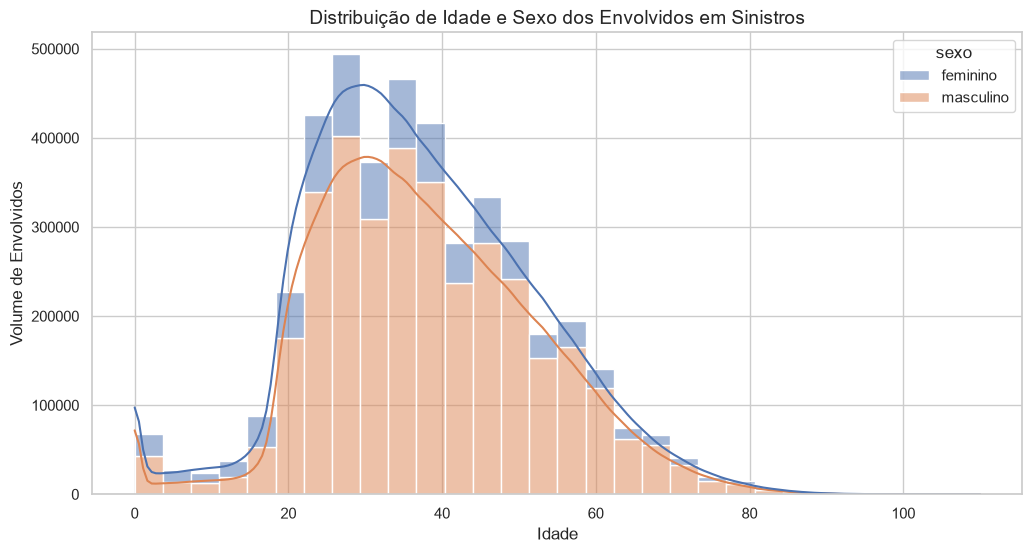

In [4]:
# Criando o gráfico
plt.figure(figsize=(12, 6))
sns.histplot(data=df_perfil, x='idade', hue='sexo', multiple="stack", bins=30, kde=True)
plt.title('Distribuição de Idade e Sexo dos Envolvidos em Sinistros', fontsize=14)
plt.xlabel('Idade')
plt.ylabel('Volume de Envolvidos')
plt.show()

sexo
feminino    2.75
masculino   2.76
Name: obito, dtype: float64

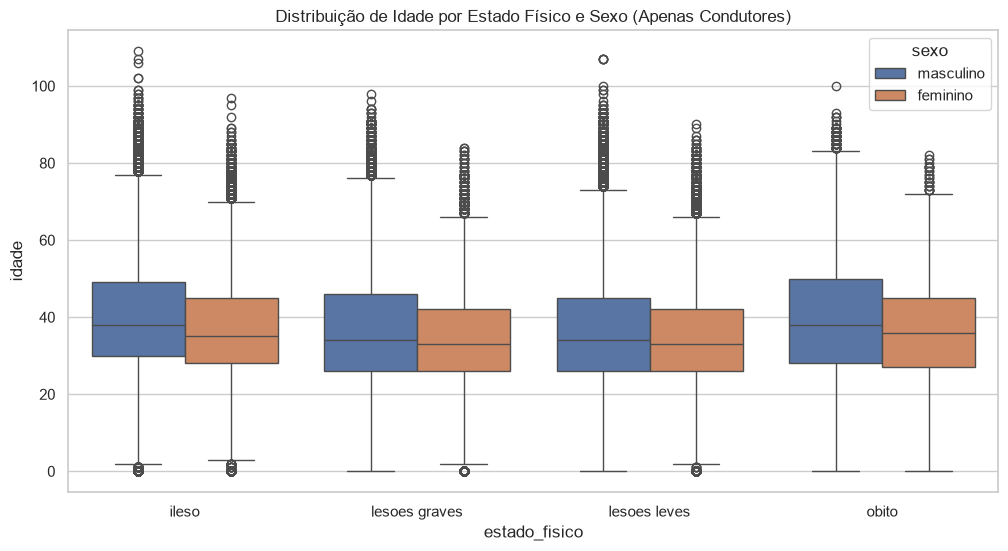

In [5]:
# Criando uma coluna booleana: 1 se morreu, 0 se não
df_perfil['obito'] = df_perfil['estado_fisico'].apply(lambda x: 1 if x == 'obito' else 0)

# Agrupando por sexo e calculando a taxa média de letalidade
taxa_letalidade_sexo = df_perfil.groupby('sexo')['obito'].mean() * 100
display(taxa_letalidade_sexo)

# Visualizando Idade vs Sexo apenas para Condutores
plt.figure(figsize=(12, 6))
condutores = df_perfil[df_perfil['tipo_envolvido'] == 'condutor']
sns.boxplot(data=condutores, x='estado_fisico', y='idade', hue='sexo')
plt.title('Distribuição de Idade por Estado Físico e Sexo (Apenas Condutores)')
plt.show()

In [7]:
taxa_letalidade_sexo = df_perfil.groupby('sexo')['obito'].mean()*100
display(taxa_letalidade_sexo)

sexo
feminino    2.75
masculino   2.76
Name: obito, dtype: float64

In [9]:
query = """
SELECT 
    dp.idade,
    dp.sexo,
    dp.tipo_envolvido,
    dp.estado_fisico,
    dt.dia_semana,
    dt.fase_dia
FROM fato f
INNER JOIN dim_pessoa dp ON f.fk_pesid = dp.pk_pessoa
INNER JOIN dim_tempo dt ON f.fk_tempo = dt.id_tempo
WHERE dp.idade >= 60
"""

# Executando a extração
df = pd.read_sql(query, engine)
print(f"Linhas extraídas: {len(df)}")

Linhas extraídas: 329923


In [ ]:
display(df.head())

,idade,sexo,tipo_envolvido,estado_fisico,dia_semana,fase_dia
0,64,masculino,condutor,ileso,domingo,pleno dia
1,60,masculino,pedestre,lesoes leves,terca-feira,pleno dia
2,69,masculino,condutor,ileso,terca-feira,pleno dia
3,60,masculino,condutor,ileso,terca-feira,pleno dia
4,82,masculino,condutor,ileso,terca-feira,pleno dia
